In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from keras.layers import Input

titanic_assignment = pd.read_csv('AAPL (1).csv')
print(titanic_assignment.head())
print(titanic_assignment.info())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100323  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.095089  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.088110  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090291   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092908   73449600
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10409 entries, 0 to 10408
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10409 non-null  object 
 1   Open       10409 non-null  float64
 2   High       10409 non-null  float64
 3   Low        10409 non-null  float64
 4   Close      10409 non-null  float64
 5   Adj Close  10409 non-null  float64
 6   Volume     10409 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 569.4+ KB
None


In [6]:
# collecting x and y

In [13]:
titanic_assignment['Date'] = pd.to_datetime(titanic_assignment['Date'])
titanic_assignment.set_index('Date', inplace=True)

In [16]:
AAPL_1 = titanic_assignment.filter(['Close'])
dataset = AAPL_1.values

In [17]:
training_data_len = int(np.ceil(len(dataset) * .8))

In [18]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

In [19]:
train_data = scaled_data[0:int(training_data_len), :]
x_train = []
y_train = []

In [20]:
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [21]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [25]:
model = Sequential()

In [26]:
model.add(Input(shape=(x_train.shape[1], 1)))

In [27]:
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

In [28]:
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=25))
model.add(Dense(units=1))

In [29]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [30]:
model.fit(x_train, y_train, batch_size=32, epochs=5)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 5.3212e-05
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 1.1942e-05
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 1.0111e-05
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 1.2712e-05
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.0780e-05


# Create testing dataset

In [31]:
test_data = scaled_data[training_data_len - 60: , :]
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [32]:
# Get predictions
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


In [35]:
# Plot the data
train = AAPL_1[:training_data_len].copy()
valid = AAPL_1[training_data_len:].copy()

In [36]:
valid['Predictions'] = predictions

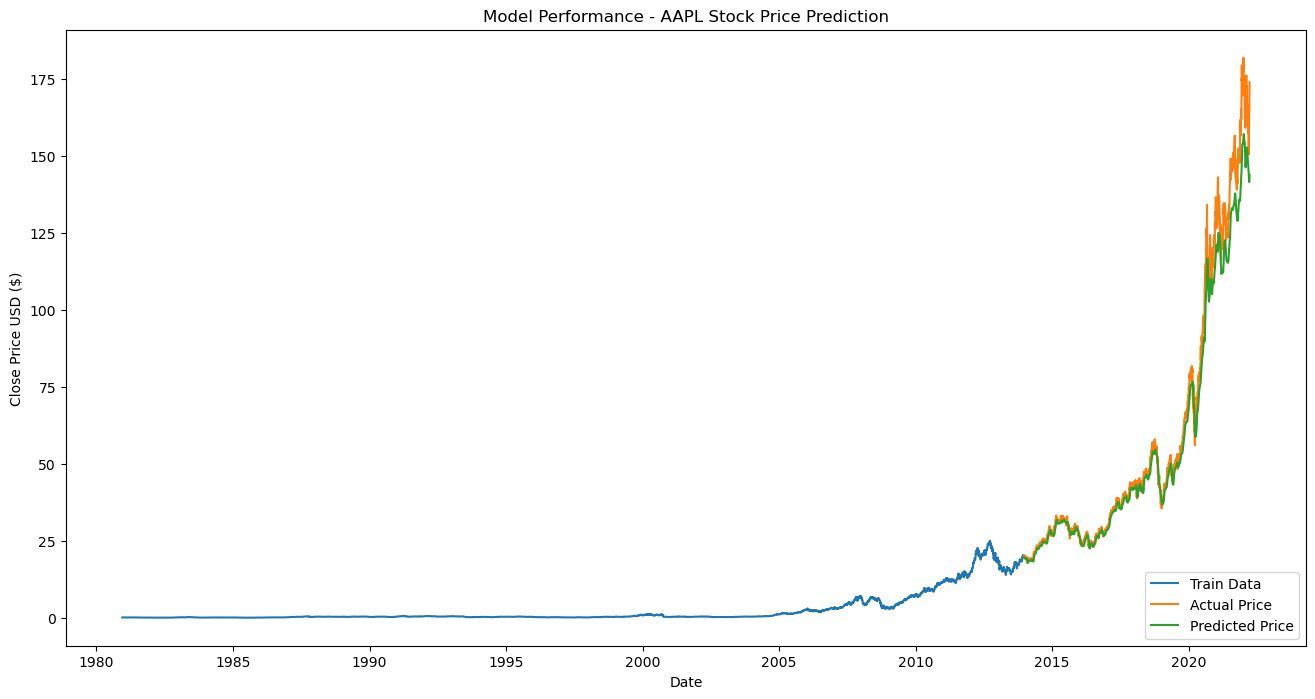

In [37]:
plt.figure(figsize=(16,8))
plt.title('Model Performance - AAPL Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(train['Close'], label='Train Data')
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend(loc='lower right')
plt.savefig('stock_prediction_results.png')

In [38]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 6.838772956451592


In [39]:
valid.to_csv('AAPL (1).csv')

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [41]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [43]:
mae = mean_absolute_error(y_test, predictions)

print(f"--- Model Accuracy Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

--- Model Accuracy Metrics ---
Root Mean Squared Error (RMSE): 6.84
Mean Absolute Error (MAE): 4.02


In [44]:
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Directional Accuracy: {100 - mape:.2f}%")

Mean Absolute Percentage Error (MAPE): 4.92%
Directional Accuracy: 95.08%
